PIPELINE MORFOLOGI UNTUK PREPROCESSING OCR DAN COUNTING OBJEK

OCR IMAGE

[KERNEL EXPERIMENT]
('RECT', (3, 3), 0.00011587142944335938)
('CROSS', (3, 3), 8.749961853027344e-05)
('ELLIPSE', (3, 3), 0.00016164779663085938)
('RECT', (5, 5), 0.00014400482177734375)
('CROSS', (5, 5), 0.00012969970703125)
('ELLIPSE', (5, 5), 0.00017023086547851562)
('RECT', (7, 7), 0.0001347064971923828)
('CROSS', (7, 7), 0.00014829635620117188)
('ELLIPSE', (7, 7), 0.0002849102020263672)

OCR RESULT:

OCR TIME: 0.15093040466308594
OCR LENGTH (proxy accuracy): 0


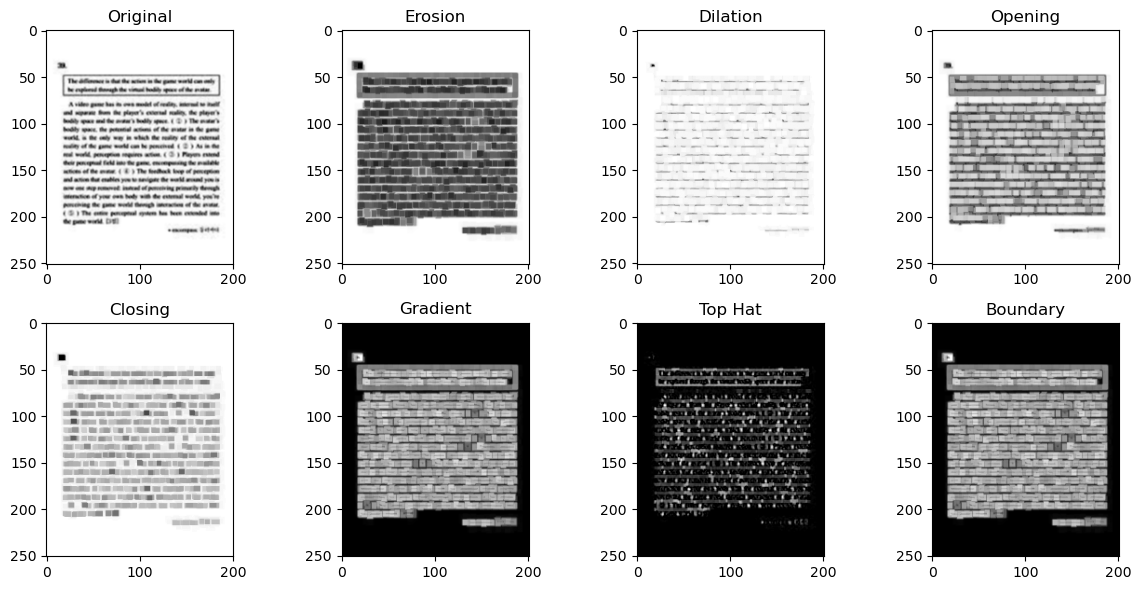


COUNT IMAGE

[KERNEL EXPERIMENT]
('RECT', (3, 3), 0.0007791519165039062)
('CROSS', (3, 3), 0.000499725341796875)
('ELLIPSE', (3, 3), 0.00042748451232910156)
('RECT', (5, 5), 0.0004978179931640625)
('CROSS', (5, 5), 0.0004870891571044922)
('ELLIPSE', (5, 5), 0.0006341934204101562)
('RECT', (7, 7), 0.0005011558532714844)
('CROSS', (7, 7), 0.0005450248718261719)
('ELLIPSE', (7, 7), 0.0009729862213134766)

COUNT RESULT:
Manual: 10
Auto  : 1
Acc   : 10.0 %


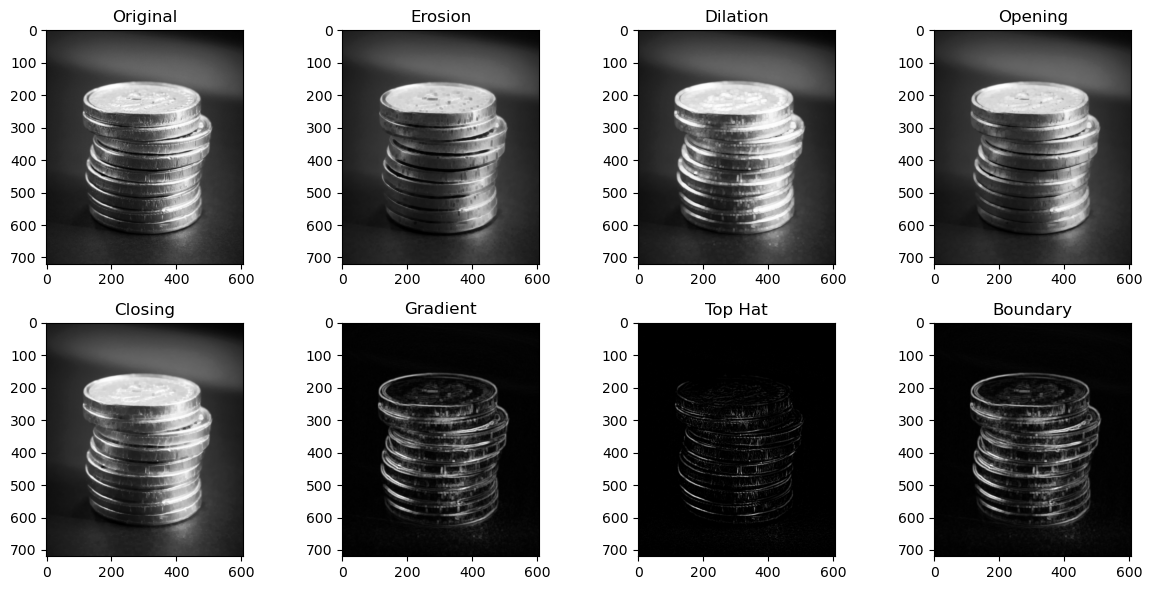

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
import pytesseract

# =========================================================
# 0. SETUP TESSERACT
# =========================================================
pytesseract.pytesseract.tesseract_cmd = r"C:\Users\acer\AppData\Local\Programs\Tesseract-OCR\tesseract.exe"

print("PIPELINE MORFOLOGI UNTUK PREPROCESSING OCR DAN COUNTING OBJEK")
print("=" * 80)

# =========================================================
# 1. LOAD IMAGE
# =========================================================
imgA = cv2.imread("teksnoise.jpg")       # OCR noisy text
imgB = cv2.imread("overlapping.jpg")     # objek bersentuhan

if imgA is None or imgB is None:
    print("Gambar tidak ditemukan!")
    exit()

# =========================================================
# 2. PREPROCESSING
# =========================================================
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    return gray, blur

grayA, blurA = preprocess(imgA)
grayB, blurB = preprocess(imgB)

# =========================================================
# 3. STRUCTURING ELEMENT
# =========================================================
sizes = [(3,3), (5,5), (7,7)]

shapes = {
    "RECT": cv2.MORPH_RECT,
    "CROSS": cv2.MORPH_CROSS,
    "ELLIPSE": cv2.MORPH_ELLIPSE
}

# =========================================================
# 4. MORPHOLOGY FUNCTIONS
# =========================================================
def erosion(img, k, it):
    return cv2.erode(img, k, iterations=it)

def dilation(img, k, it):
    return cv2.dilate(img, k, iterations=it)

def boundary(img, k):
    return cv2.absdiff(cv2.dilate(img,k), cv2.erode(img,k))

def morph_ops(img, k):
    opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, k)
    closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k)
    gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, k)
    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, k)
    blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, k)
    return opening, closing, gradient, tophat, blackhat

# =========================================================
# 5. OCR PIPELINE
# =========================================================
def ocr_pipeline(img):
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))

    # noise removal dulu
    cleaned = cv2.morphologyEx(img, cv2.MORPH_OPEN, k)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, k)

    th = cv2.threshold(cleaned, 0, 255,
                       cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    start = time.time()
    text = pytesseract.image_to_string(th)
    end = time.time()

    return th, text, end-start

# =========================================================
# 6. COUNTING (WATERSHED FIXED)
# =========================================================
def counting_pipeline(img):

    k = np.ones((3,3), np.uint8)

    blur = cv2.GaussianBlur(img, (5,5), 0)
    _, binary = cv2.threshold(blur, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k, iterations=2)

    sure_bg = cv2.dilate(opening, k, iterations=2)

    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, 0.4*dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)

    unknown = cv2.subtract(sure_bg, sure_fg)

    markers = cv2.connectedComponents(sure_fg)[1]
    markers = markers + 1
    markers[unknown == 255] = 0

    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    markers = cv2.watershed(img_color, markers)

    count = len(np.unique(markers)) - 2

    return markers, count

# =========================================================
# 7. KERNEL EXPERIMENT
# =========================================================
def kernel_experiment(img):
    results = []

    for size in sizes:
        for name, shape in shapes.items():

            k = cv2.getStructuringElement(shape, size)

            start = time.time()
            cv2.morphologyEx(img, cv2.MORPH_OPEN, k)
            cv2.morphologyEx(img, cv2.MORPH_CLOSE, k)
            t = time.time() - start

            results.append((name, size, t))

    return results

# =========================================================
# 8. ANALYSIS LOOP
# =========================================================
dataset = [("OCR IMAGE", blurA), ("COUNT IMAGE", blurB)]

for name, img in dataset:

    print("\n==============================")
    print(name)
    print("==============================")

    # ================= KERNEL =================
    print("\n[KERNEL EXPERIMENT]")
    kernel_results = kernel_experiment(img)
    for r in kernel_results:
        print(r)

    # ================= EROSION / DILATION =================
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

    er1 = erosion(img,k,1)
    er2 = erosion(img,k,2)
    di1 = dilation(img,k,1)
    di2 = dilation(img,k,2)

    # ================= MORPH OPS =================
    op, cl, gr, th, bh = morph_ops(img,k)

    # ================= BOUNDARY =================
    bd = boundary(img,k)

    # ================= OCR =================
    if "OCR" in name:
        ocr_img, text, t = ocr_pipeline(img)

        print("\nOCR RESULT:")
        print(text)
        print("OCR TIME:", t)

        print("OCR LENGTH (proxy accuracy):", len(text))

    # ================= COUNTING =================
    if "COUNT" in name:
        markers, count = counting_pipeline(img)

        manual = 10
        acc = (count / manual) * 100

        print("\nCOUNT RESULT:")
        print("Manual:", manual)
        print("Auto  :", count)
        print("Acc   :", acc, "%")

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))

    plt.subplot(2,4,1); plt.imshow(img, cmap='gray'); plt.title("Original")
    plt.subplot(2,4,2); plt.imshow(er1, cmap='gray'); plt.title("Erosion")
    plt.subplot(2,4,3); plt.imshow(di1, cmap='gray'); plt.title("Dilation")
    plt.subplot(2,4,4); plt.imshow(op, cmap='gray'); plt.title("Opening")

    plt.subplot(2,4,5); plt.imshow(cl, cmap='gray'); plt.title("Closing")
    plt.subplot(2,4,6); plt.imshow(gr, cmap='gray'); plt.title("Gradient")
    plt.subplot(2,4,7); plt.imshow(th, cmap='gray'); plt.title("Top Hat")
    plt.subplot(2,4,8); plt.imshow(bd, cmap='gray'); plt.title("Boundary")

    plt.tight_layout()
    plt.show()